# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-12: HR TYrPPG Training (screening pass)

### What this notebook does
Trains TYrPPG (Mambaout-based Gated Video Understanding Block, Chen et al., arXiv 2511.05833, IEEE WI-IAT'25 AI4SG) on the three preprocessed datasets (MCD + UBFC-rPPG + DLCN) as the fourth architecture in the screen-then-tune plan. Same pipeline as NB_P3_08/09/10: committed loader with multi-clip sampling, subject-wise split, temporal-rescale + hflip augmentation, cardiac_sqi soft-weighting, neg-Pearson + frequency loss, and the honest per-dataset / resting / Bland-Altman evaluation. Compared against PhysNet (val HR MAE ~8).

### TYrPPG notes
- Repo: github.com/Taixi-CHEN/TYrPPG, rPPG-Toolbox-based. Reported to beat PhysFormer and RhythmFormer.
- Architecture: a Gated Video Understanding Block (GVB) with the Mambaout structure + 3D-CNN - **no selective-scan SSM, so NO mamba-ssm / causal-conv1d / triton dependency** (reliable on Kaggle; the reason it is on the shortlist).
- Loss: the paper proposes a Comprehensive Supervised Loss (CSL, 3 terms); for this first-pass SCREEN we reuse our neg-Pearson + frequency-match loss to keep it comparable across architectures.
- Hyperparameters: sane rPPG-Toolbox defaults (Adam, lr 1e-3, cosine, 30 epochs) - the repo YAML holds the paper values, which become tuning knobs later.

### Implementation risks (read before running)
The repo is brand-new (Nov 2025), so the exact model class name / constructor / input orientation cannot be verified from here. **Section 3 auto-discovers the class and prints an nn.Module listing if it cannot** - paste that + any Section 5 sanity error and it will be pinned (same quick loop as PhysFormer/RhythmMamba). The forward runs in fp32 (preempts any internal-FFT cuFFT-half crash). No frames are rendered.

## 1. Imports & Config (+ clone TYrPPG)

In [1]:
import os, sys, time, random, glob, importlib
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# Clone TYrPPG and expose it on the path (no mamba-ssm needed - Mambaout has no SSM kernel).
if not os.path.exists('TYrPPG'):
    os.system('git clone --depth 1 https://github.com/Taixi-CHEN/TYrPPG')
sys.path.append('TYrPPG')
for d in glob.glob('TYrPPG/**/', recursive=True):
    sys.path.append(d)
os.system('pip install einops timm -q')

DATA_DIR = Path('/kaggle/input/datasets/cezarytubacki/phase3-hr-train-dataset')

# Auto-discover H5 files in the dataset
H5_FILES = sorted([f.name for f in DATA_DIR.glob('*.h5')])

CLIP_LEN = 160
IMG_SIZE = 72
BATCH_SIZE = 8
CLIPS_PER_REC = 2
NUM_WORKERS = 2
VAL_FRAC = 0.2
SEED = 42

AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_FLOOR = 0.05

LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 20
LAMBDA_FREQ = 0.2
HR_LOW, HR_HIGH = 0.66, 3.0

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True
print('device:', device, '| DATA_DIR:', DATA_DIR)
print('files present:', [fn for fn in H5_FILES if (DATA_DIR / fn).exists()])

Cloning into 'TYrPPG'...


device: cuda | DATA_DIR: /kaggle/input/datasets/cezarytubacki/phase3-hr-train-dataset
files present: ['dlcn_phase3.h5', 'mcd_phase3.h5', 'ubfc_rppg_phase3.h5']


## 2. Data Loader - index, subject-wise split, dataset (multi-clip sampling)

In [2]:
def build_index(data_dir, h5_files, sqi_floor=SQI_FLOOR, clip_len=CLIP_LEN):
    index = []
    for fn in h5_files:
        path = Path(data_dir) / fn
        if not path.exists():
            print('missing', path); continue
        with h5py.File(path, 'r') as f:
            for name in f.keys():
                a = f[name].attrs
                if not bool(a.get('usable', True)):
                    continue
                if float(a.get('cardiac_sqi', 0.0)) < sqi_floor:
                    continue
                n = int(a['n_frames'])
                if n < clip_len:
                    continue
                index.append(dict(file=fn, group=name, dataset=str(a.get('dataset', fn)),
                                  subject=str(a.get('subject_id', name)), n_frames=n,
                                  fps=float(a.get('fps', 30.0)), sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


def subject_split(index, val_frac=VAL_FRAC, seed=SEED):
    subjects = sorted({r['dataset'] + '/' + r['subject'] for r in index})
    rng = random.Random(seed); rng.shuffle(subjects)
    n_val = max(1, int(round(len(subjects) * val_frac)))
    val_subj = set(subjects[:n_val])
    tr = [r for r in index if (r['dataset'] + '/' + r['subject']) not in val_subj]
    va = [r for r in index if (r['dataset'] + '/' + r['subject']) in val_subj]
    return tr, va, val_subj


def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    def __init__(self, index, data_dir, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.data_dir = Path(data_dir); self.clip_len = clip_len
        self.augment = augment; self.clips_per_rec = clips_per_rec
        self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def _h5(self, fn):
        h = self._files.get(fn)
        if h is None:
            h = h5py.File(self.data_dir / fn, 'r'); self._files[fn] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len].astype(np.float32)
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        m = frames.mean(axis=(0, 1, 2), keepdims=True); sd = frames.std(axis=(0, 1, 2), keepdims=True) + 1e-6
        frames = np.ascontiguousarray((frames - m) / sd)
        frames = torch.from_numpy(frames).permute(3, 0, 1, 2).float()
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        bvp = torch.from_numpy(bvp.astype(np.float32))
        return dict(frames=frames, bvp=bvp,
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, DATA_DIR, augment=augment, clips_per_rec=clips_per_rec)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
                      worker_init_fn=worker_init_fn, pin_memory=True, drop_last=augment,
                      persistent_workers=(NUM_WORKERS > 0))

## 3. Model - TYrPPG (official repo)

In [3]:
# Auto-discover the TYrPPG model class (repo is new; class name / path not verified from here).
TYrPPGClass = None
for modname in ['neural_methods.model.TYrPPG', 'model.TYrPPG', 'TYrPPG', 'neural_methods.model.GVB']:
    for cls in ['TYrPPG', 'GVB', 'Model', 'Net']:
        try:
            m = importlib.import_module(modname)
            if hasattr(m, cls):
                TYrPPGClass = getattr(m, cls)
                print('imported', cls, 'from', modname)
                break
        except Exception as e:
            pass
    if TYrPPGClass is not None:
        break

if TYrPPGClass is None:
    print('TYrPPG class not auto-found. nn.Module classes in repo:')
    for pyf in glob.glob('TYrPPG/**/*.py', recursive=True):
        try:
            for line in open(pyf, errors='ignore'):
                s = line.strip()
                if s.startswith('class ') and 'Module' in s:
                    print('   ', pyf.split('TYrPPG/')[-1], '->', s)
        except Exception:
            pass
    raise RuntimeError('Could not auto-import TYrPPG - paste the class listing to pin it.')


def build_tyrppg():
    last = None
    for kw in [dict(), dict(frames=CLIP_LEN), dict(frame=CLIP_LEN), dict(dim=96)]:
        try:
            return TYrPPGClass(**kw)
        except Exception as e:
            last = e
    raise last


def ty_forward(model, x):
    '''Our clips are [B,C,T,H,W]; rPPG-Toolbox convention is [B,T,C,H,W]. fp32 to preempt internal-FFT cuFFT-half issues. Returns [B,T].'''
    xx = x.permute(0, 2, 1, 3, 4).contiguous().float()
    with torch.autocast('cuda', enabled=False):
        out = model(xx)
    if isinstance(out, (tuple, list)):
        out = out[0]
    if out.dim() == 3 and out.shape[-1] == 1:
        out = out.squeeze(-1)
    if out.dim() == 3 and out.shape[1] == 1:
        out = out.squeeze(1)
    return out

imported TYrPPG from TYrPPG


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


## 4. Losses & Evaluation Functions

In [4]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def freq_loss(pred, target, fps=30.0, low=HR_LOW, high=HR_HIGH):
    pred = pred.float(); target = target.float()
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    Pp = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Pt = torch.abs(torch.fft.rfft(target, dim=1)) ** 2
    freqs = torch.fft.rfftfreq(pred.shape[1], 1.0 / fps).to(pred.device)
    band = (freqs >= low) & (freqs <= high)
    Pp = Pp[:, band]; Pt = Pt[:, band]
    Pp = Pp / (Pp.sum(dim=1, keepdim=True) + 1e-8)
    Pt = Pt / (Pt.sum(dim=1, keepdim=True) + 1e-8)
    return ((Pp - Pt) ** 2).sum(dim=1)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader, tag='val'):
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        pred = ty_forward(model, frames).float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        print('  no valid eval clips'); return 1e9
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    mae = float(df.ae.mean()); rmse = float(np.sqrt(((df.hr_pred - df.hr_true) ** 2).mean()))
    r = float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan')
    print(f'  [{tag}] MAE {mae:.2f} | RMSE {rmse:.2f} | r {r:.3f} | n {len(df)}')
    print('   per-dataset MAE:', df.groupby('dataset')['ae'].mean().round(2).to_dict())
    rest = df[df.hr_true < 90]
    if len(rest):
        print(f'   resting <90bpm MAE {rest.ae.mean():.2f} (n {len(rest)})')
    return mae

## 5. Sanity Check

In [5]:
index = build_index(DATA_DIR, H5_FILES)
print('usable recordings:', len(index), '| by dataset:', dict(Counter(r['dataset'] for r in index)))
train_idx, val_idx, val_subj = subject_split(index)
print('train recs:', len(train_idx), '| val recs:', len(val_idx), '| val subjects:', len(val_subj))

train_loader = make_loader(train_idx, augment=True, clips_per_rec=CLIPS_PER_REC)
val_loader = make_loader(val_idx, augment=False, clips_per_rec=1)
print('train clips/epoch:', len(train_loader.dataset), '| val clips:', len(val_loader.dataset))

model = build_tyrppg().to(device)
print('TYrPPG params:', round(sum(p.numel() for p in model.parameters()) / 1e6, 2), 'M')

batch = next(iter(train_loader))
print('batch frames', tuple(batch['frames'].shape), '| bvp', tuple(batch['bvp'].shape))
with torch.no_grad():
    out = ty_forward(model, batch['frames'][:2].to(device))
print('model output', tuple(out.shape), '(expect [2,', CLIP_LEN, '])')

usable recordings: 2010 | by dataset: {'DLCN': 777, 'MCD': 1191, 'UBFC-rPPG': 42}
train recs: 1585 | val recs: 425 | val subjects: 148
train clips/epoch: 3170 | val clips: 425
TYrPPG params: 2.85 M
batch frames (8, 3, 160, 72, 72) | bvp (8, 160)
model output (2, 160) (expect [2, 160 ])


## 6. Training

In [6]:
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

best = 1e9
for epoch in range(EPOCHS):
    model.train(); tot = 0.0; nb = 0; t0 = time.time()
    for batch in train_loader:
        frames = batch['frames'].to(device, non_blocking=True)
        bvp = batch['bvp'].to(device, non_blocking=True)
        sqi = batch['sqi'].to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        pred = ty_forward(model, frames)
        per = neg_pearson(pred, bvp) + LAMBDA_FREQ * freq_loss(pred, bvp)
        w = sqi.clamp(min=1e-3)
        loss = (per * w).sum() / w.sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tot += float(loss.item()); nb += 1
    sched.step()
    print(f'epoch {epoch + 1}/{EPOCHS} | train_loss {tot / max(nb, 1):.4f} | {time.time() - t0:.0f}s')
    mae = evaluate(model, val_loader)
    if mae < best:
        best = mae; torch.save(model.state_dict(), 'tyrppg_best.pt'); print('   * new best', round(best, 2))

torch.save(model.state_dict(), 'tyrppg_last.pt')
print('DONE | best val HR MAE:', round(best, 2), '(PhysNet baseline was 8.07)')

epoch 1/20 | train_loss 1.0985 | 1612s
  [val] MAE 18.74 | RMSE 27.11 | r 0.185 | n 425
   per-dataset MAE: {'DLCN': 11.74, 'MCD': 24.15, 'UBFC-rPPG': 22.18}
   resting <90bpm MAE 13.91 (n 190)
   * new best 18.74
epoch 2/20 | train_loss 1.0101 | 1587s
  [val] MAE 14.85 | RMSE 23.37 | r 0.287 | n 425
   per-dataset MAE: {'DLCN': 8.01, 'MCD': 20.57, 'UBFC-rPPG': 5.57}
   resting <90bpm MAE 13.20 (n 190)
   * new best 14.85
epoch 3/20 | train_loss 0.9631 | 1577s
  [val] MAE 16.80 | RMSE 26.89 | r 0.116 | n 425
   per-dataset MAE: {'DLCN': 9.66, 'MCD': 22.74, 'UBFC-rPPG': 8.35}
   resting <90bpm MAE 9.55 (n 190)
epoch 4/20 | train_loss 0.9364 | 1574s
  [val] MAE 16.51 | RMSE 26.30 | r 0.223 | n 425
   per-dataset MAE: {'DLCN': 9.42, 'MCD': 22.69, 'UBFC-rPPG': 0.0}
   resting <90bpm MAE 11.16 (n 190)
epoch 5/20 | train_loss 0.9251 | 1560s
  [val] MAE 18.20 | RMSE 28.72 | r 0.105 | n 425
   per-dataset MAE: {'DLCN': 10.03, 'MCD': 24.85, 'UBFC-rPPG': 12.54}
   resting <90bpm MAE 10.97 (n 190

## 7. Post-training Evaluation & Bland-Altman

eval clips: 425
               n    MAE   RMSE  bias     SD  LoA_low  LoA_high  Pearson_r
DLCN       184.0   7.52  17.73 -6.05  16.71   -38.80     26.70       0.51
MCD        233.0  13.61  21.36 -8.97  19.42   -47.04     29.09       0.38
UBFC-rPPG    8.0   2.80   5.59 -2.80   5.18   -12.94      7.35       0.91
ALL        425.0  10.77  19.66 -7.59  18.16   -43.19     28.00       0.45


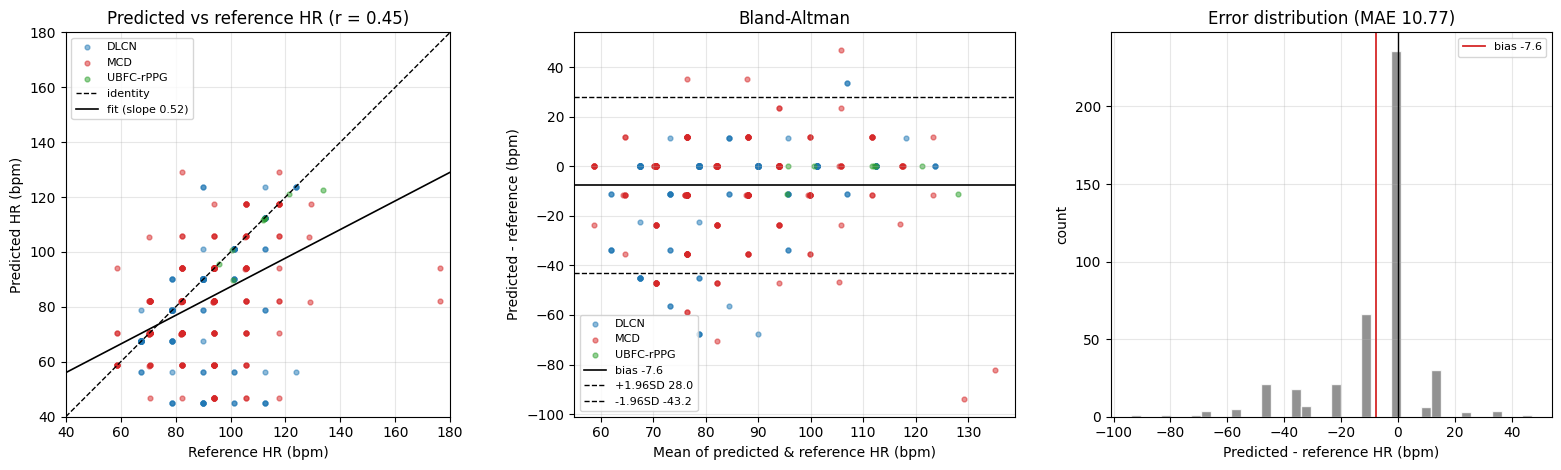

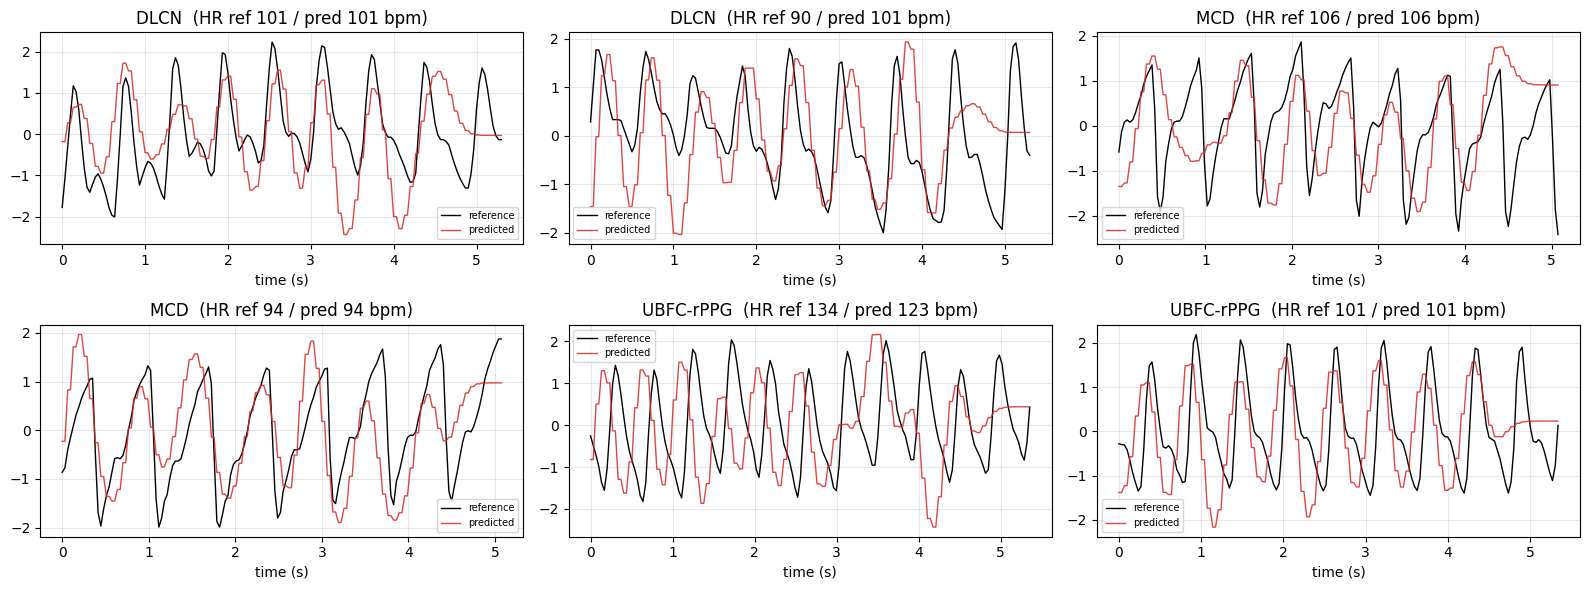

In [7]:
model.load_state_dict(torch.load('tyrppg_best.pt', map_location=device))
model.eval()

@torch.no_grad()
def collect_predictions(model, loader, waves_per_ds=2):
    rows, waves, wave_ct = [], [], {}
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        pred = ty_forward(model, frames).float().cpu().numpy(); bvp = batch['bvp'].numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if not np.isfinite(hp):
                continue
            rows.append((ds[i], float(hr_true[i]), hp))
            if wave_ct.get(ds[i], 0) < waves_per_ds:
                waves.append((ds[i], float(fps[i]), bvp[i].copy(), pred[i].copy()))
                wave_ct[ds[i]] = wave_ct.get(ds[i], 0) + 1
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred']), waves

pred_df, wave_examples = collect_predictions(model, val_loader)
print('eval clips:', len(pred_df))


def metrics_block(g):
    d = (g['hr_pred'] - g['hr_true']).values
    sd = d.std(ddof=1) if len(d) > 1 else np.nan
    return pd.Series({'n': len(g), 'MAE': np.abs(d).mean(), 'RMSE': np.sqrt((d ** 2).mean()),
                     'bias': d.mean(), 'SD': sd, 'LoA_low': d.mean() - 1.96 * sd,
                     'LoA_high': d.mean() + 1.96 * sd,
                     'Pearson_r': np.corrcoef(g['hr_true'], g['hr_pred'])[0, 1] if len(g) > 2 else np.nan})

summary = pred_df.groupby('dataset').apply(metrics_block, include_groups=False)
overall = metrics_block(pred_df); overall.name = 'ALL'
print(pd.concat([summary, overall.to_frame().T]).round(2).to_string())

colors = {'MCD': 'tab:red', 'DLCN': 'tab:blue', 'UBFC-rPPG': 'tab:green'}
diff = (pred_df.hr_pred - pred_df.hr_true).values
bias, sd = diff.mean(), diff.std(ddof=1)
r = np.corrcoef(pred_df.hr_true, pred_df.hr_pred)[0, 1]
lim = [40, 180]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
for ds, gdf in pred_df.groupby('dataset'):
    ax[0].scatter(gdf.hr_true, gdf.hr_pred, s=12, alpha=0.5, color=colors.get(ds, 'gray'), label=ds)
ax[0].plot(lim, lim, 'k--', lw=1, label='identity')
slope, intc = np.polyfit(pred_df.hr_true, pred_df.hr_pred, 1)
ax[0].plot(np.array(lim), intc + slope * np.array(lim), 'k-', lw=1.2, label=f'fit (slope {slope:.2f})')
ax[0].set(xlim=lim, ylim=lim, xlabel='Reference HR (bpm)', ylabel='Predicted HR (bpm)',
          title=f'Predicted vs reference HR (r = {r:.2f})', aspect='equal')
ax[0].legend(fontsize=8, loc='upper left'); ax[0].grid(alpha=0.3)
for ds, gdf in pred_df.groupby('dataset'):
    m = (gdf.hr_true + gdf.hr_pred) / 2; d = gdf.hr_pred - gdf.hr_true
    ax[1].scatter(m, d, s=12, alpha=0.5, color=colors.get(ds, 'gray'), label=ds)
ax[1].axhline(bias, color='k', lw=1.2, label=f'bias {bias:.1f}')
ax[1].axhline(bias + 1.96 * sd, color='k', ls='--', lw=1, label=f'+1.96SD {bias + 1.96 * sd:.1f}')
ax[1].axhline(bias - 1.96 * sd, color='k', ls='--', lw=1, label=f'-1.96SD {bias - 1.96 * sd:.1f}')
ax[1].set(xlabel='Mean of predicted & reference HR (bpm)', ylabel='Predicted - reference (bpm)', title='Bland-Altman')
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
ax[2].hist(diff, bins=40, color='tab:gray', alpha=0.85, edgecolor='white')
ax[2].axvline(0, color='k', lw=1); ax[2].axvline(bias, color='tab:red', lw=1.3, label=f'bias {bias:.1f}')
ax[2].set(xlabel='Predicted - reference HR (bpm)', ylabel='count',
          title=f'Error distribution (MAE {np.abs(diff).mean():.2f})')
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 6))
for k, (ds, fps, bt, bp) in enumerate(wave_examples[:6]):
    axr = axes[k // 3, k % 3]
    bt = (bt - bt.mean()) / (bt.std() + 1e-6); bp = (bp - bp.mean()) / (bp.std() + 1e-6)
    t = np.arange(len(bt)) / fps
    axr.plot(t, bt, color='k', lw=1.0, label='reference')
    axr.plot(t, bp, color='tab:red', lw=1.0, alpha=0.85, label='predicted')
    axr.set(title=f'{ds}  (HR ref {hr_from_bvp(bt, fps):.0f} / pred {hr_from_bvp(bp, fps):.0f} bpm)', xlabel='time (s)')
    axr.legend(fontsize=7); axr.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
def clip_sqi(bvp, fps, low=0.7, high=3.5):
    '''3-bin peak-power fraction of the reference BVP = how trustworthy this clip's true-HR label is.'''
    x = np.asarray(bvp, float); x = x - x.mean()
    if x.std() < 1e-8:
        return 0.0
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return 0.0
    pk = int(np.argmax(p[b]))
    return float(p[b][max(0, pk - 1):pk + 2].sum() / p[b].sum())

FWD = lambda f: ty_forward(model, f) # TYrPPG forward (fp32, [B,T,C,H,W] handled inside)

@torch.no_grad()
def collect_with_sqi(model, loader, fwd):
    model.eval(); rows = []
    for batch in loader:
        frames = batch['frames'].to(device, non_blocking=True)
        pred = fwd(frames).float().cpu().numpy()      # ty_forward already runs fp32 - no autocast
        bvp = batch['bvp'].numpy(); hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if not np.isfinite(hp):
                continue
            rows.append((ds[i], float(hr_true[i]), hp, clip_sqi(bvp[i], float(fps[i]))))
    return pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred', 'ref_sqi'])

df = collect_with_sqi(model, val_loader, FWD)
df['ae'] = (df.hr_pred - df.hr_true).abs()
print('total eval clips:', len(df))
for thr in [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]:
    sub = df[df.ref_sqi >= thr]
    if len(sub) < 5:
        continue
    r = np.corrcoef(sub.hr_true, sub.hr_pred)[0, 1] if len(sub) > 2 else float('nan')
    pds = sub.groupby('dataset')['ae'].mean().round(2).to_dict()
    print(f'ref_sqi>={thr:.2f} | n {len(sub):4d} | MAE {sub.ae.mean():5.2f} | r {r:.3f} | per-dataset {pds}')

total eval clips: 425
ref_sqi>=0.00 | n  425 | MAE 10.77 | r 0.454 | per-dataset {'DLCN': 7.52, 'MCD': 13.61, 'UBFC-rPPG': 2.8}
ref_sqi>=0.05 | n  425 | MAE 10.77 | r 0.454 | per-dataset {'DLCN': 7.52, 'MCD': 13.61, 'UBFC-rPPG': 2.8}
ref_sqi>=0.10 | n  425 | MAE 10.77 | r 0.454 | per-dataset {'DLCN': 7.52, 'MCD': 13.61, 'UBFC-rPPG': 2.8}
ref_sqi>=0.15 | n  425 | MAE 10.77 | r 0.454 | per-dataset {'DLCN': 7.52, 'MCD': 13.61, 'UBFC-rPPG': 2.8}
ref_sqi>=0.20 | n  425 | MAE 10.77 | r 0.454 | per-dataset {'DLCN': 7.52, 'MCD': 13.61, 'UBFC-rPPG': 2.8}
ref_sqi>=0.30 | n  425 | MAE 10.77 | r 0.454 | per-dataset {'DLCN': 7.52, 'MCD': 13.61, 'UBFC-rPPG': 2.8}
